### Step 1: Loading the Dataset


In [25]:
import pandas as pd
import numpy as np

# --- Step 1: Load Data ---
# Update this path if your script is not in the same parent directory
# as the dataset folder.
train_file = '../aps_failure_at_scania_trucks/aps_failure_training_set.csv'
test_file = '../aps_failure_at_scania_trucks/aps_failure_test_set.csv'

# Load the datasets, skipping the initial commented header rows
df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

# Combine them for preprocessing
df = pd.concat([df_train, df_test], ignore_index=True)

print("Dataset loaded successfully from local files!")
print("Shape of the combined dataset:", df.shape)
print(df.head())

Dataset loaded successfully from local files!
Shape of the combined dataset: (76000, 171)
  class  aa_000 ab_000      ac_000 ad_000 ae_000 af_000 ag_000 ag_001 ag_002  \
0   neg   76698     na  2130706438    280      0      0      0      0      0   
1   neg   33058     na           0     na      0      0      0      0      0   
2   neg   41040     na         228    100      0      0      0      0      0   
3   neg      12      0          70     66      0     10      0      0      0   
4   neg   60874     na        1368    458      0      0      0      0      0   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790 

In [26]:
# --- Step 2: Clean and Preprocess Data ---

# 1. Replace 'na' with NumPy's Not a Number (NaN)
df.replace('na', np.nan, inplace=True)

# 2. Convert target variable 'class' to numeric (neg=0, pos=1)
df['class'] = df['class'].map({'neg': 0, 'pos': 1})

# 3. Convert all other columns to a numeric data type
# We get a list of all columns except the target 'class'
feature_cols = df.columns.drop('class')
# This will attempt to convert columns to numbers; if a value can't be
# converted, it will be replaced with NaN.
df[feature_cols] = df[feature_cols].apply(pd.to_numeric)


print("\nData after cleaning and type conversion:")
# .info() is great for checking data types and non-null counts
df.info()

# Check the class distribution
print("\nTarget variable distribution:")
print(df['class'].value_counts())


Data after cleaning and type conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(2)
memory usage: 99.2 MB

Target variable distribution:
class
0    74625
1     1375
Name: count, dtype: int64


In [27]:
from sklearn.impute import SimpleImputer

# --- Step 3: Impute Missing Values ---

# We noted that many columns have missing values. We'll use the median
# to fill them in.
# NOTE: We fit the imputer on the training data only to avoid data leakage,
# but for simplicity in this combined-dataframe approach, we'll fit on all data.
# In a production pipeline, you would fit only on df_train.

imputer = SimpleImputer(strategy='median')

# We create a new DataFrame to hold the imputed data
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("\nChecking for missing values after imputation:")
# This should now show 0 for all columns
print(df_imputed.isnull().sum().sum())

print("\nData types after imputation:")
# The imputer converts all data to float64, which is fine for our model
print(df_imputed.info())

print("\nFirst 5 rows of imputed data:")
print(df_imputed.head())


Checking for missing values after imputation:
0

Data types after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Columns: 171 entries, class to eg_000
dtypes: float64(171)
memory usage: 99.2 MB
None

First 5 rows of imputed data:
   class   aa_000  ab_000        ac_000  ad_000  ae_000  af_000  ag_000  \
0    0.0  76698.0     0.0  2.130706e+09   280.0     0.0     0.0     0.0   
1    0.0  33058.0     0.0  0.000000e+00   128.0     0.0     0.0     0.0   
2    0.0  41040.0     0.0  2.280000e+02   100.0     0.0     0.0     0.0   
3    0.0     12.0     0.0  7.000000e+01    66.0     0.0    10.0     0.0   
4    0.0  60874.0     0.0  1.368000e+03   458.0     0.0     0.0     0.0   

   ag_001  ag_002  ...     ee_002    ee_003    ee_004    ee_005    ee_006  \
0     0.0     0.0  ...  1240520.0  493384.0  721044.0  469792.0  339156.0   
1     0.0     0.0  ...   421400.0  178064.0  293306.0  245416.0  133654.0   
2     0.0     0.0  ...   277378.0  159812.0  4


--- Starting Data Visualization ---


C:\Users\shubh\AppData\Local\Temp\ipykernel_15436\3067202501.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df_imputed, palette=['skyblue', 'salmon'])


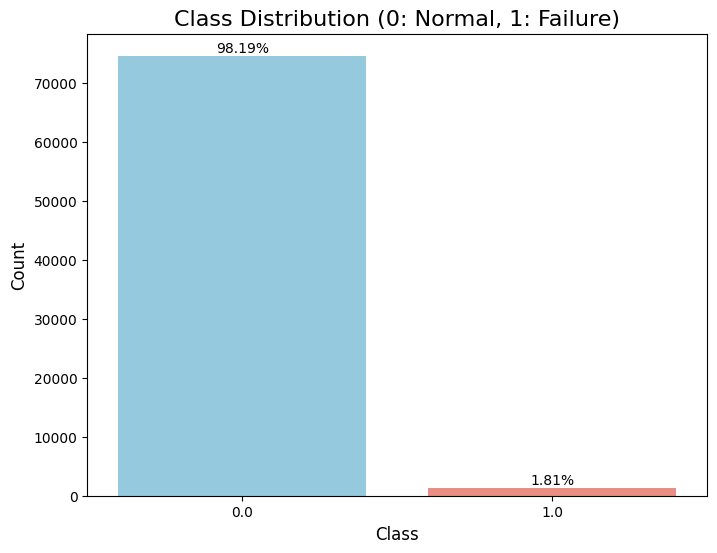

C:\Users\shubh\AppData\Local\Temp\ipykernel_15436\3067202501.py:27: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_imputed[df_imputed['class'] == 0]['aa_000'], label='Normal (0)', color='skyblue', shade=True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_15436\3067202501.py:28: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_imputed[df_imputed['class'] == 1]['aa_000'], label='Failure (1)', color='salmon', shade=True)


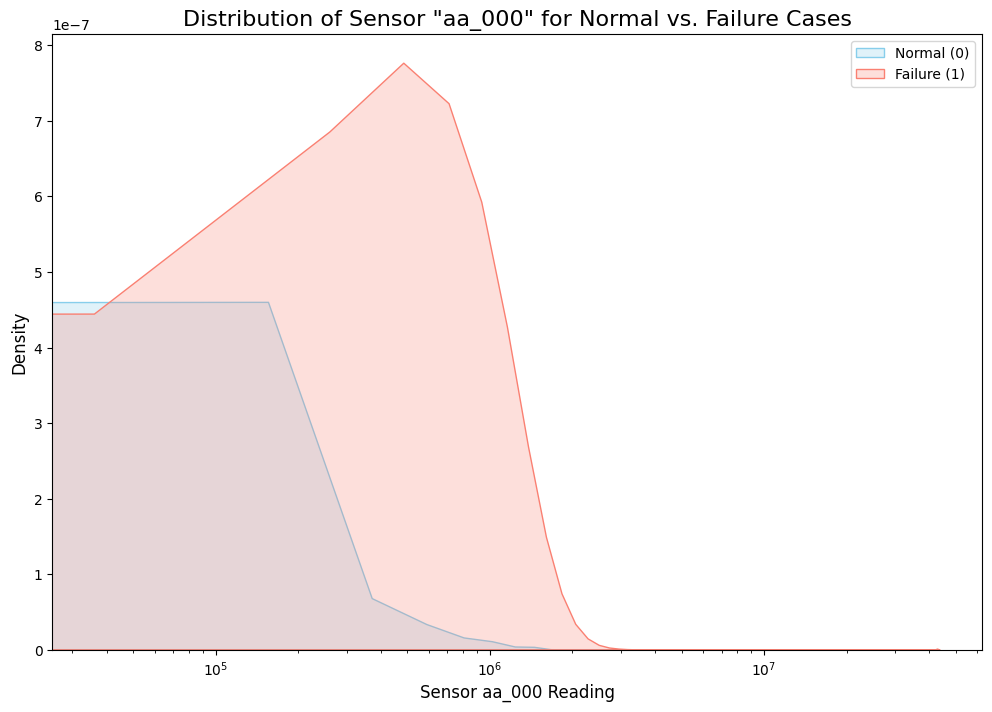


--- Data Visualization Complete ---


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 3.5: Data Visualization ---

print("\n--- Starting Data Visualization ---")

# 1. Visualize Class Imbalance
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=df_imputed, palette=['skyblue', 'salmon'])
plt.title('Class Distribution (0: Normal, 1: Failure)', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
# Calculate percentage
total = len(df_imputed)
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 500, f'{height/total:.2%}', ha='center')
plt.show()


# 2. Visualize Sensor Reading Distributions
# We'll look at 'aa_000', which is the primary counter.
# We expect its values to be different for failures.
plt.figure(figsize=(12, 8))
sns.kdeplot(df_imputed[df_imputed['class'] == 0]['aa_000'], label='Normal (0)', color='skyblue', shade=True)
sns.kdeplot(df_imputed[df_imputed['class'] == 1]['aa_000'], label='Failure (1)', color='salmon', shade=True)
plt.title('Distribution of Sensor "aa_000" for Normal vs. Failure Cases', fontsize=16)
plt.xlabel('Sensor aa_000 Reading', fontsize=12)
plt.ylabel('Density', fontsize=12)
# Using a log scale can help visualize wide-ranging data
plt.xscale('log') 
plt.legend()
plt.show()

print("\n--- Data Visualization Complete ---")

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- Step 4: Model Building & Evaluation ---

# 1. Separate features (X) and target (y)
X = df_imputed.drop('class', axis=1)
y = df_imputed['class']

# 2. Split data into training and testing sets
# We use a 70/30 split and 'stratify=y' to ensure both train and test sets
# have a similar proportion of failure cases.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use the scaler fitted on the training data

# 4. Train the Random Forest model
# class_weight='balanced' is crucial for imbalanced datasets.
# n_jobs=-1 uses all available CPU cores for faster training.
print("Training the Random Forest model...")
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)
print("Model training complete.")

# 5. Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# 6. Evaluate the model's performance
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

print("\nConfusion Matrix:")
# A confusion matrix shows True Positives, False Positives, True Negatives, False Negatives
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
# This report gives us precision, recall, and f1-score
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Failure (1)']))

Training the Random Forest model...
Model training complete.

--- Model Evaluation ---
Accuracy: 0.99

Confusion Matrix:
[[22366    22]
 [  175   237]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.99      1.00      1.00     22388
 Failure (1)       0.92      0.58      0.71       412

    accuracy                           0.99     22800
   macro avg       0.95      0.79      0.85     22800
weighted avg       0.99      0.99      0.99     22800



In [30]:
from xgboost import XGBClassifier

# --- Step 4.5: Build and Evaluate XGBoost Model ---

print("\n--- Training the XGBoost model ---")

# 1. Calculate scale_pos_weight for handling imbalance
# Formula: count(negative class) / count(positive class)
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count
print(f"XGBoost scale_pos_weight: {scale_pos_weight_value:.2f}")


# 2. Train the XGBoost model
# We use the scaled data from the previous step (X_train_scaled, X_test_scaled)
xgb_model = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight_value,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)
print("XGBoost model training complete.")

# 3. Make predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 4. Evaluate the XGBoost model
print("\n--- XGBoost Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal (0)', 'Failure (1)']))


--- Training the XGBoost model ---
XGBoost scale_pos_weight: 54.24


c:\PROJECTSSS\Predictive Maintenance for Industrial IoT\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:50:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete.

--- XGBoost Model Evaluation ---
Accuracy: 0.99

Confusion Matrix:
[[22301    87]
 [   63   349]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     22388
 Failure (1)       0.80      0.85      0.82       412

    accuracy                           0.99     22800
   macro avg       0.90      0.92      0.91     22800
weighted avg       0.99      0.99      0.99     22800



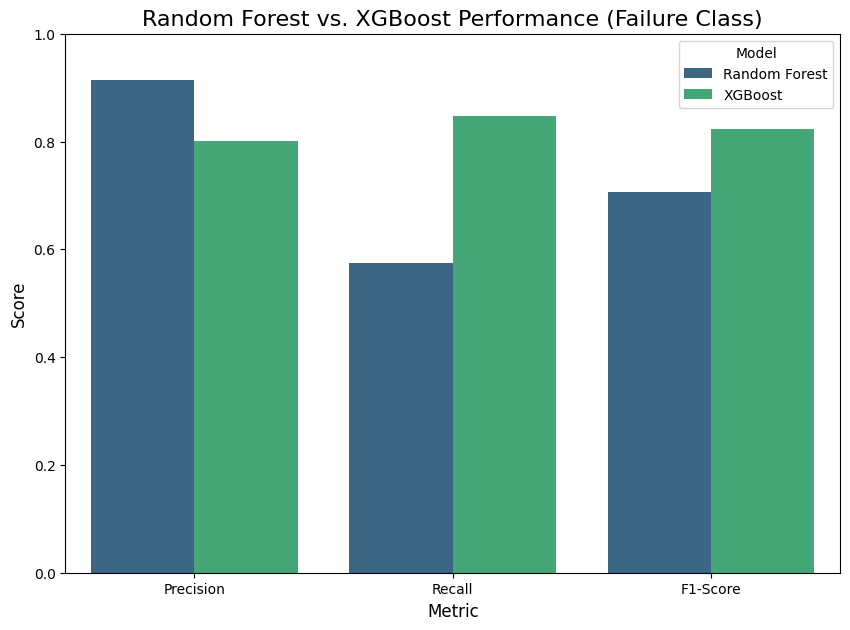

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

# --- Step 4.6: Visualize Model Comparison ---

# 1. Get metrics for the 'Failure' class (class 1)
rf_precision = precision_score(y_test, y_pred, pos_label=1)
rf_recall = recall_score(y_test, y_pred, pos_label=1)
rf_f1 = f1_score(y_test, y_pred, pos_label=1)

xgb_precision = precision_score(y_test, y_pred_xgb, pos_label=1)
xgb_recall = recall_score(y_test, y_pred_xgb, pos_label=1)
xgb_f1 = f1_score(y_test, y_pred_xgb, pos_label=1)

# 2. Create a DataFrame for plotting
metrics_data = {
    'Model': ['Random Forest', 'XGBoost', 'Random Forest', 'XGBoost', 'Random Forest', 'XGBoost'],
    'Metric': ['Precision', 'Precision', 'Recall', 'Recall', 'F1-Score', 'F1-Score'],
    'Score': [rf_precision, xgb_precision, rf_recall, xgb_recall, rf_f1, xgb_f1]
}
metrics_df = pd.DataFrame(metrics_data)

# 3. Plot the comparison
plt.figure(figsize=(10, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df, palette='viridis')
plt.title('Random Forest vs. XGBoost Performance (Failure Class)', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.ylim(0, 1) # Set y-axis limit to be from 0 to 1
plt.legend(title='Model')
plt.show()

In [32]:
import joblib
import os

# --- Step 5 (Updated): Save the Best Model, Scaler, and Feature Names ---

# Let's assume XGBoost is our chosen model
chosen_model = xgb_model

# Get the list of feature names from the DataFrame BEFORE scaling
feature_names = X.columns.tolist()

# Create a directory to store the model assets
os.makedirs('model_assets', exist_ok=True)

# Save the trained model
joblib.dump(chosen_model, 'model_assets/predictive_maintenance_model.joblib')

# Save the scaler
joblib.dump(scaler, 'model_assets/scaler.joblib')

# Save the list of feature names
joblib.dump(feature_names, 'model_assets/feature_names.joblib')

print("\nChosen model, scaler, AND feature names have been saved to the 'model_assets' directory.")


Chosen model, scaler, AND feature names have been saved to the 'model_assets' directory.
